# Clase 5 — Aprendizaje Automatico
## K-Nearest Neighbors (KNN) y Árbol de Decisión



### Objetivo
Implementar y comparar los algoritmos **K-Nearest Neighbors (KNN)** y **Árbol de Decisión** sobre el dataset **Iris**, evaluando la precisión de cada clasificador e identificando sus fortalezas y debilidades.

### Dataset elegido: Iris
El conjunto de datos Iris contiene mediciones de 150 flores de tres especies:
- *Iris Setosa*
- *Iris Versicolor*
- *Iris Virginica*

**Características:** largo y ancho del sépalo, largo y ancho del pétalo (4 features numéricas).
**Variable objetivo:** especie (3 clases discretas).

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, accuracy_score)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
print("Librerias importadas correctamente")

Librerias importadas correctamente


---
## 1. Carga y Exploración del Dataset Iris

In [3]:
# Cargar el dataset Iris desde scikit-learn
iris = load_iris()

# Convertir a DataFrame para mejor visualización
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['especie'] = iris.target
df['nombre_especie'] = [iris.target_names[i] for i in iris.target]

print(f"Shape: {df.shape}")
print(f"Clases: {list(iris.target_names)}")
print()
print("Distribucion de clases:")
print(df['nombre_especie'].value_counts())
print()
print("Estadisticas descriptivas:")
display(df.drop('especie', axis=1).describe().round(2))

Shape: (150, 6)
Clases: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

Distribucion de clases:
nombre_especie
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Estadisticas descriptivas:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


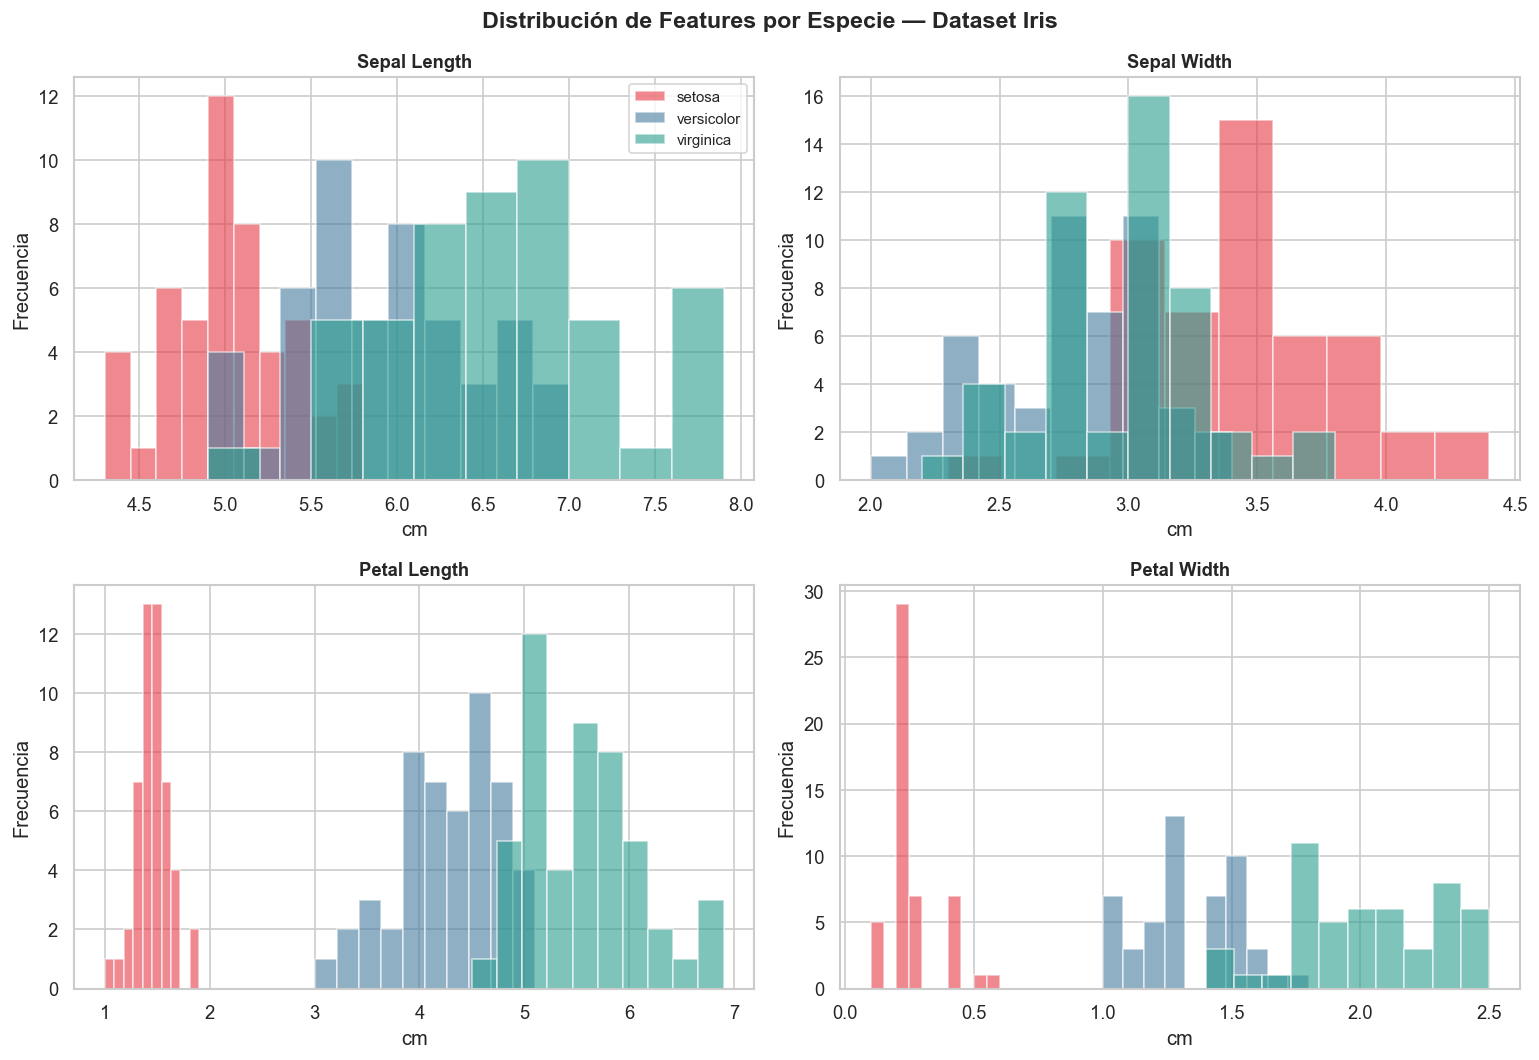

Interpretacion:
  Petal length y petal width separan claramente Setosa del resto.
  Sepal length y sepal width muestran mayor solapamiento entre Versicolor y Virginica.


In [4]:
#Visualización EDA: distribuciones y scatter 
COLORES = ['#e63946', '#457b9d', '#2a9d8f']
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()
features = iris.feature_names

for i, feat in enumerate(features):
    for j, (label, color) in enumerate(zip(iris.target_names, COLORES)):
        datos = df.loc[df['nombre_especie'] == label, feat]
        axes[i].hist(datos, bins=10, alpha=0.6, color=color, label=label, edgecolor='white')
    axes[i].set_title(feat.replace('(cm)', '').strip().title(), fontsize=11, fontweight='bold')
    axes[i].set_xlabel('cm')
    axes[i].set_ylabel('Frecuencia')
    if i == 0:
        axes[i].legend(fontsize=9)

fig.suptitle('Distribución de Features por Especie — Dataset Iris',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Interpretacion:")
print("  Petal length y petal width separan claramente Setosa del resto.")
print("  Sepal length y sepal width muestran mayor solapamiento entre Versicolor y Virginica.")

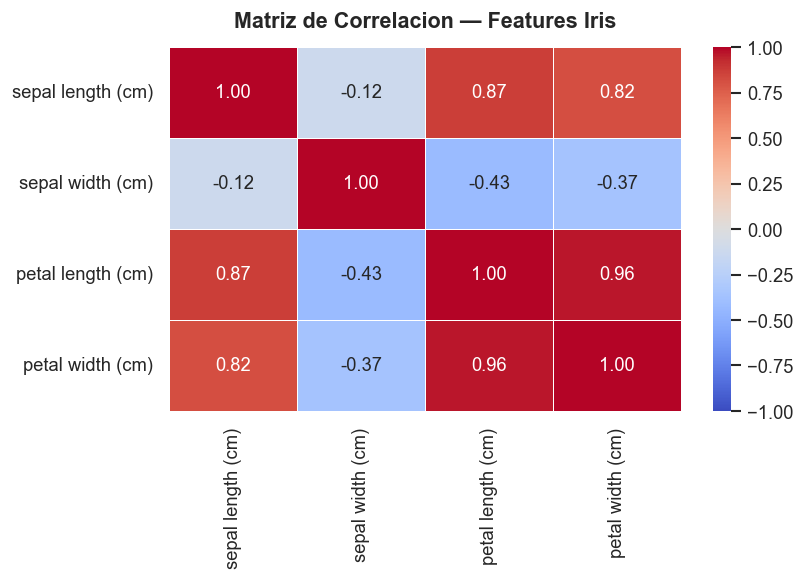

Petal length - petal width: r=0.96 (correlacion muy fuerte positiva)


In [5]:
# Heatmap de correlaciones 
fig, ax = plt.subplots(figsize=(7, 5))
corr = df[iris.feature_names].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f',
            vmin=-1, vmax=1, center=0, linewidths=0.5,
            annot_kws={"size": 11}, ax=ax)
ax.set_title('Matriz de Correlacion — Features Iris', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

print("Petal length - petal width: r=0.96 (correlacion muy fuerte positiva)")

---
## 2. Preparación de los datos

In [6]:
# Usamos las 4 features completas para los modelos
X = iris.data
y = iris.target

# Train/test split estratificado (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Estandarización (necesaria para KNN)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print()
print("Proporcion de clases en train:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {iris.target_names[u]}: {c} ({c/len(y_train)*100:.1f}%)")
print()
print("Proporcion de clases en test:")
unique, counts = np.unique(y_test, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {iris.target_names[u]}: {c} ({c/len(y_test)*100:.1f}%)")

X_train: (120, 4)  |  X_test: (30, 4)

Proporcion de clases en train:
  setosa: 40 (33.3%)
  versicolor: 40 (33.3%)
  virginica: 40 (33.3%)

Proporcion de clases en test:
  setosa: 10 (33.3%)
  versicolor: 10 (33.3%)
  virginica: 10 (33.3%)


---
## 3. Algoritmo K-Nearest Neighbors (KNN)

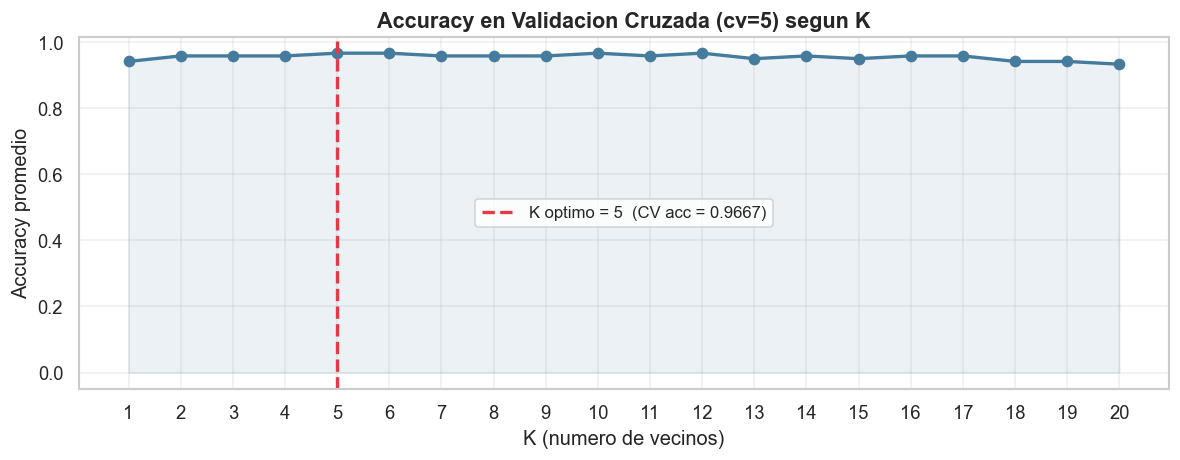

K optimo seleccionado: 5  |  Accuracy CV: 0.9667


In [7]:
#Busqueda del K optimo con validacion cruzada 
k_range = range(1, 21)
acc_cv = []
for k in k_range:
    knn_tmp = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_tmp, X_train_sc, y_train, cv=5, scoring='accuracy')
    acc_cv.append(scores.mean())

k_optimo = list(k_range)[np.argmax(acc_cv)]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(list(k_range), acc_cv, marker='o', color='#457b9d', lw=2, markersize=6)
ax.axvline(k_optimo, color='#e63946', linestyle='--', lw=2,
           label=f'K optimo = {k_optimo}  (CV acc = {max(acc_cv):.4f})')
ax.fill_between(list(k_range), acc_cv, alpha=0.1, color='#457b9d')
ax.set_title('Accuracy en Validacion Cruzada (cv=5) segun K', fontsize=13, fontweight='bold')
ax.set_xlabel('K (numero de vecinos)')
ax.set_ylabel('Accuracy promedio')
ax.set_xticks(list(k_range))
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"K optimo seleccionado: {k_optimo}  |  Accuracy CV: {max(acc_cv):.4f}")

  MODELO 1 — K-Nearest Neighbors (k = 5)
  Accuracy en TRAIN: 0.9750  (97.5%)
  Accuracy en TEST:  0.9333  (93.3%)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



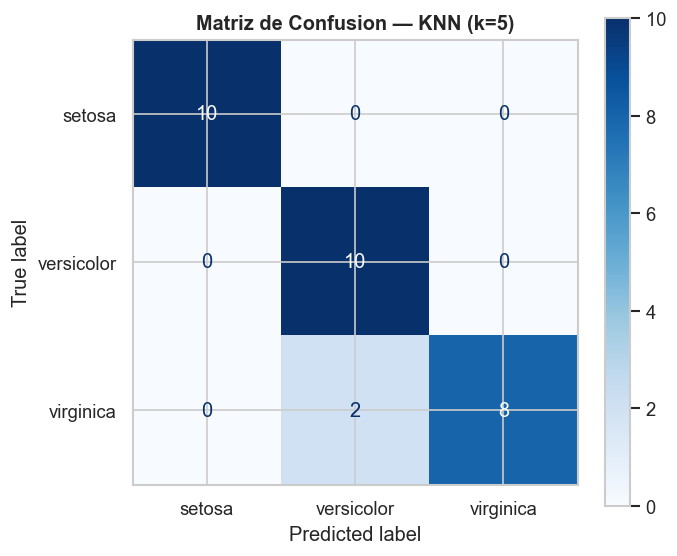

In [8]:
# KNN: entrenamiento y evaluacion
print("=" * 58)
print(f"  MODELO 1 — K-Nearest Neighbors (k = {k_optimo})")
print("=" * 58)

knn = KNeighborsClassifier(n_neighbors=k_optimo)
knn.fit(X_train_sc, y_train)
y_pred_knn = knn.predict(X_test_sc)

acc_knn_train = knn.score(X_train_sc, y_train)
acc_knn_test  = accuracy_score(y_test, y_pred_knn)

print(f"  Accuracy en TRAIN: {acc_knn_train:.4f}  ({acc_knn_train*100:.1f}%)")
print(f"  Accuracy en TEST:  {acc_knn_test:.4f}  ({acc_knn_test*100:.1f}%)")
print()
print(classification_report(y_test, y_pred_knn, target_names=iris.target_names))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_knn,
    display_labels=iris.target_names,
    cmap='Blues', ax=ax
)
ax.set_title(f'Matriz de Confusion — KNN (k={k_optimo})', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

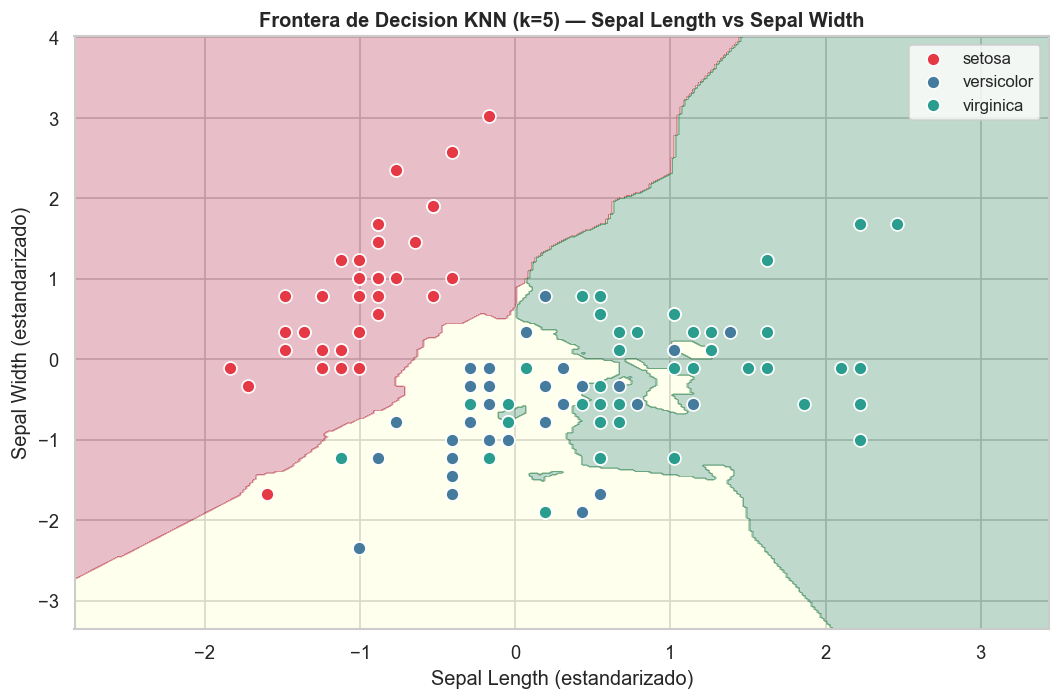

Accuracy KNN (2 features) en test: 0.6333


In [9]:
#Visualizacion frontera de decision KNN (primeras 2 features) 
X2 = X[:, :2]   # sepal length y sepal width
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y, test_size=0.2, random_state=42, stratify=y)
sc2 = StandardScaler()
X2_train_sc = sc2.fit_transform(X2_train)
X2_test_sc  = sc2.transform(X2_test)

knn2 = KNeighborsClassifier(n_neighbors=k_optimo)
knn2.fit(X2_train_sc, y2_train)

# Mallado
h = 0.02
x_min, x_max = X2_train_sc[:, 0].min()-1, X2_train_sc[:, 0].max()+1
y_min, y_max = X2_train_sc[:, 1].min()-1, X2_train_sc[:, 1].max()+1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

Z = knn2.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

fig, ax = plt.subplots(figsize=(9, 6))
ax.contourf(xx, yy, Z, alpha=0.25, cmap=plt.cm.get_cmap('RdYlGn', 3))
for cls, color in zip(range(3), COLORES):
    mask = y2_train == cls
    ax.scatter(X2_train_sc[mask, 0], X2_train_sc[mask, 1],
               color=color, label=iris.target_names[cls], edgecolors='white',
               s=60, zorder=5)
ax.set_title(f'Frontera de Decision KNN (k={k_optimo}) — Sepal Length vs Sepal Width',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Sepal Length (estandarizado)')
ax.set_ylabel('Sepal Width (estandarizado)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"Accuracy KNN (2 features) en test: {knn2.score(X2_test_sc, y2_test):.4f}")

---
## 4. Árbol de Decisión

  MODELO 2 — Arbol de Decision (max_depth=3)
  Accuracy en TRAIN: 0.9833  (98.3%)
  Accuracy en TEST:  0.9667  (96.7%)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



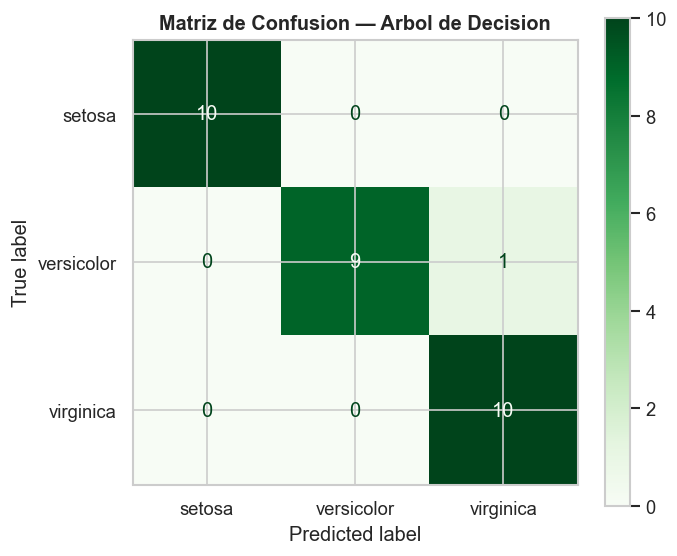

In [10]:
# Decision Tree: entrenamiento y evaluacion 
print("=" * 58)
print("  MODELO 2 — Arbol de Decision (max_depth=3)")
print("=" * 58)

dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train, y_train)         # DT no requiere estandarizacion
y_pred_dt = dt.predict(X_test)

acc_dt_train = dt.score(X_train, y_train)
acc_dt_test  = accuracy_score(y_test, y_pred_dt)

print(f"  Accuracy en TRAIN: {acc_dt_train:.4f}  ({acc_dt_train*100:.1f}%)")
print(f"  Accuracy en TEST:  {acc_dt_test:.4f}  ({acc_dt_test*100:.1f}%)")
print()
print(classification_report(y_test, y_pred_dt, target_names=iris.target_names))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_dt,
    display_labels=iris.target_names,
    cmap='Greens', ax=ax
)
ax.set_title('Matriz de Confusion — Arbol de Decision', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

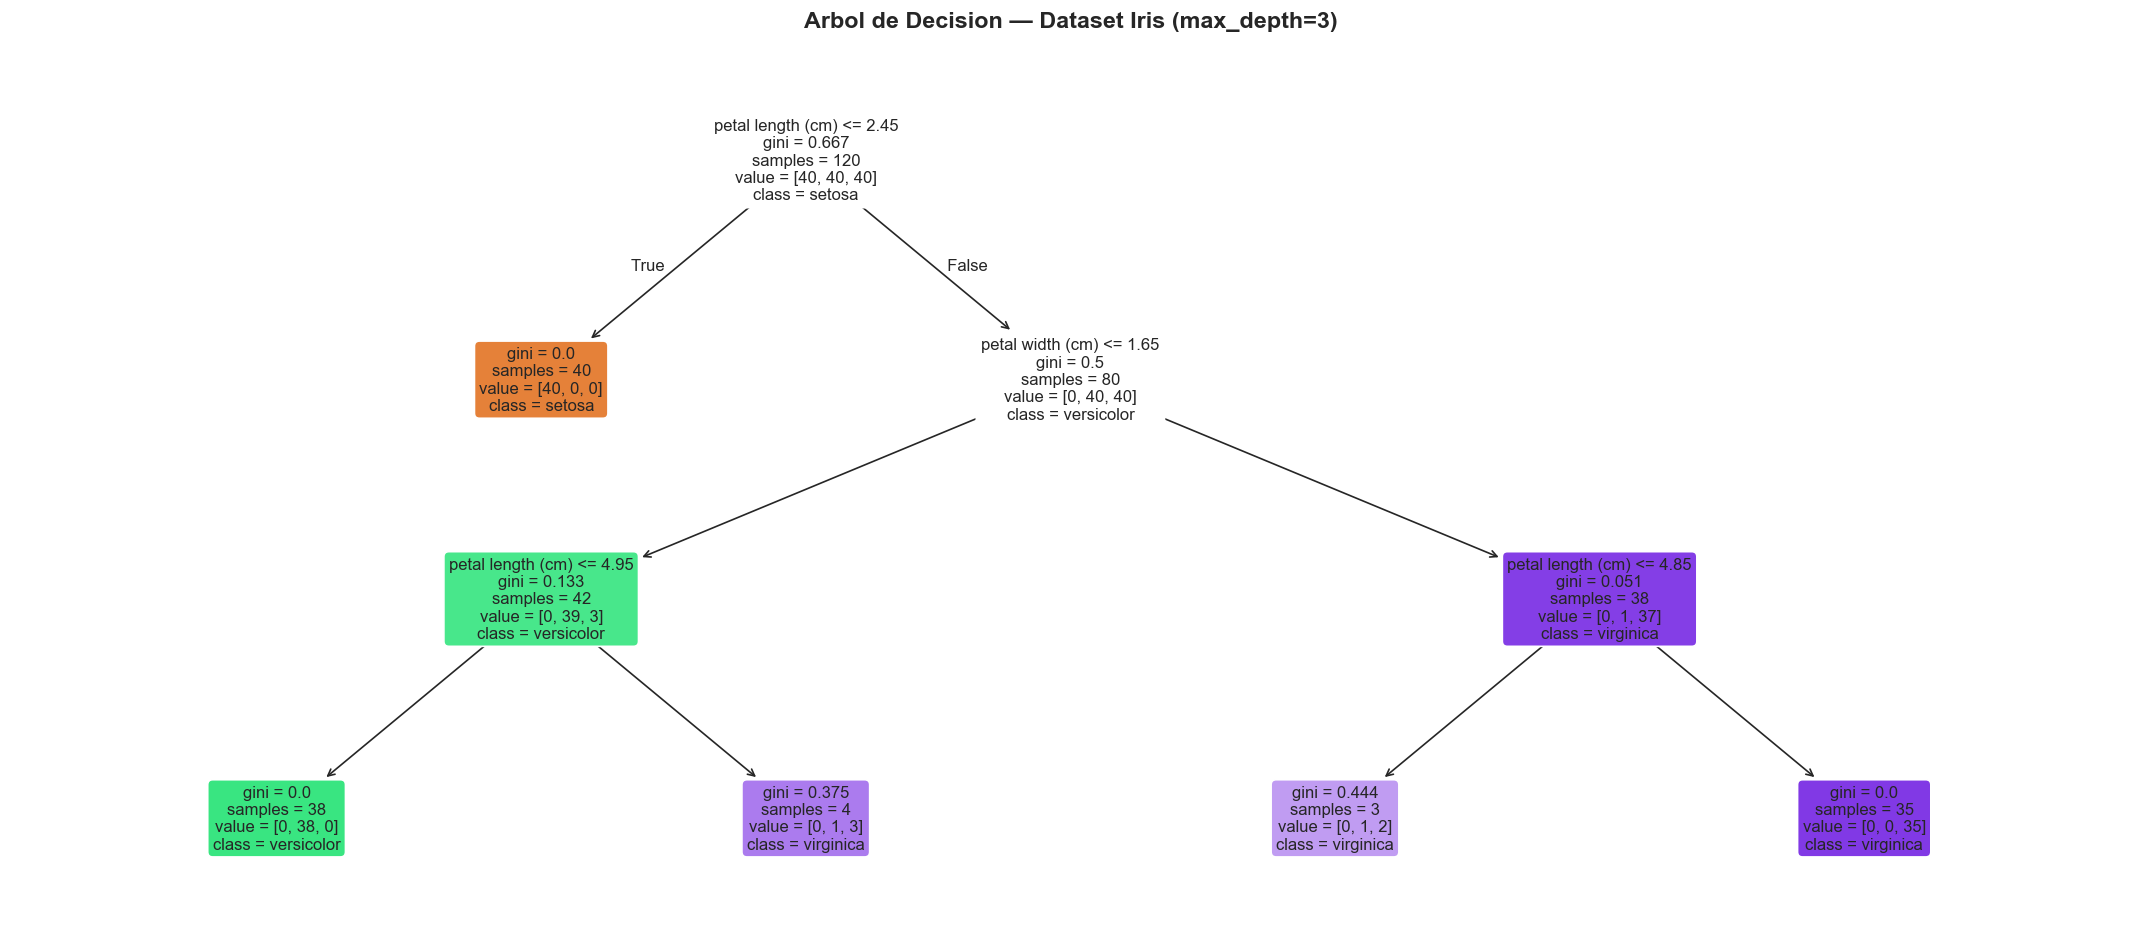

In [11]:
#Visualizacion del arbol 
fn = ['sepal length (cm)', 'sepal width (cm)',
      'petal length (cm)', 'petal width (cm)']
cn = list(iris.target_names)

fig, ax = plt.subplots(figsize=(18, 8))
plot_tree(dt,
          feature_names=fn,
          class_names=cn,
          filled=True, rounded=True,
          fontsize=10, ax=ax,
          impurity=True)
ax.set_title('Arbol de Decision — Dataset Iris (max_depth=3)',
             fontsize=14, fontweight='bold', pad=14)
plt.tight_layout()
plt.show()

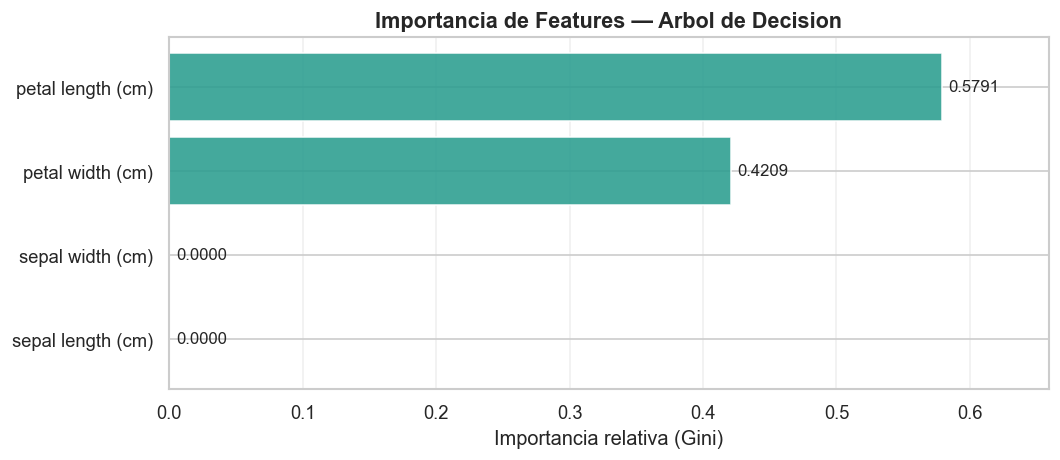

Importancia de features:
petal length (cm)    0.5791
petal width (cm)     0.4209
sepal width (cm)     0.0000
sepal length (cm)    0.0000


In [12]:
# Importancia de features 
feat_imp = pd.Series(dt.feature_importances_, index=fn).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 4))
colores_bar = ['#2a9d8f' if v > 0.1 else '#adb5bd' for v in feat_imp.values]
bars = ax.barh(feat_imp.index, feat_imp.values,
               color=colores_bar, edgecolor='white', alpha=0.88)
for bar, val in zip(bars, feat_imp.values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)
ax.set_title('Importancia de Features — Arbol de Decision',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importancia relativa (Gini)')
ax.set_xlim(0, feat_imp.max() + 0.08)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("Importancia de features:")
print(feat_imp.sort_values(ascending=False).round(4).to_string())

---
## 5. Comparativa KNN vs Árbol de Decisión

  TABLA COMPARATIVA DE MODELOS
                     Modelo  Acc Train  Acc Test  F1 macro  Precision  Recall
                  KNN (k=5)     0.9750    0.9333    0.9327     0.9444  0.9333
Arbol de Decision (depth=3)     0.9833    0.9667    0.9666     0.9697  0.9667



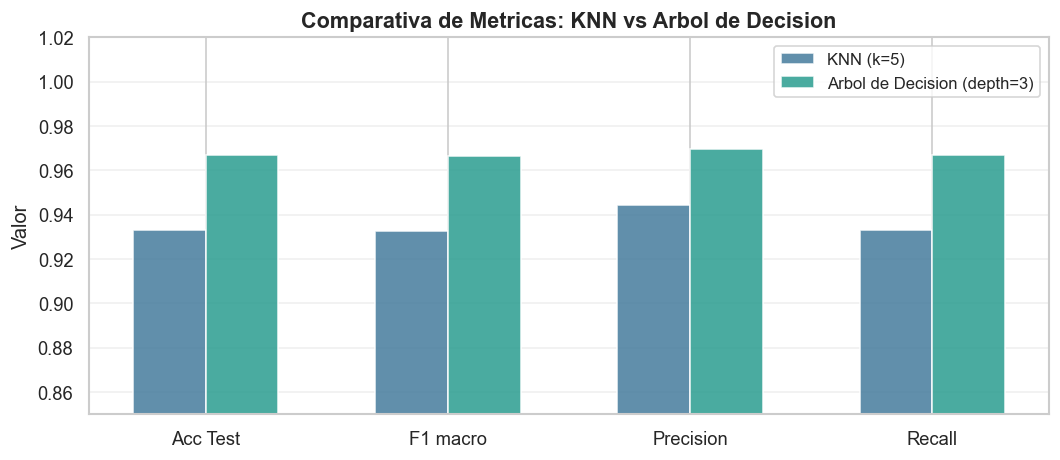

In [13]:
from sklearn.metrics import f1_score, precision_score, recall_score

comp = pd.DataFrame({
    'Modelo':        [f'KNN (k={k_optimo})', 'Arbol de Decision (depth=3)'],
    'Acc Train':     [round(acc_knn_train, 4), round(acc_dt_train, 4)],
    'Acc Test':      [round(acc_knn_test,  4), round(acc_dt_test,  4)],
    'F1 macro':      [round(f1_score(y_test, y_pred_knn, average='macro'), 4),
                      round(f1_score(y_test, y_pred_dt,  average='macro'), 4)],
    'Precision':     [round(precision_score(y_test, y_pred_knn, average='macro'), 4),
                      round(precision_score(y_test, y_pred_dt,  average='macro'), 4)],
    'Recall':        [round(recall_score(y_test, y_pred_knn, average='macro'), 4),
                      round(recall_score(y_test, y_pred_dt,  average='macro'), 4)],
})


print("  TABLA COMPARATIVA DE MODELOS")

print(comp.to_string(index=False))
print()

# Grafico comparativo
fig, ax = plt.subplots(figsize=(9, 4))
metricas = ['Acc Test', 'F1 macro', 'Precision', 'Recall']
x = np.arange(len(metricas))
w = 0.3
ax.bar(x - w/2, [comp.loc[0, m] for m in metricas], width=w,
       color='#457b9d', alpha=0.85, label=comp.loc[0,'Modelo'], edgecolor='white')
ax.bar(x + w/2, [comp.loc[1, m] for m in metricas], width=w,
       color='#2a9d8f', alpha=0.85, label=comp.loc[1,'Modelo'], edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(metricas, fontsize=11)
ax.set_ylim(0.85, 1.02)
ax.set_ylabel('Valor')
ax.set_title('Comparativa de Metricas: KNN vs Arbol de Decision',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## 6. Conclusiones

### Resultados obtenidos

| Modelo | Acc Train | Acc Test | F1 macro | Observación |
|--------|-----------|----------|----------|-------------|
| KNN (k=5) | 97.5% | 93.3% | 0.9327 | Sensible a escala → requiere StandardScaler |
| Árbol de Decisión (depth=3) | 98.3% | **96.7%** | **0.9666** | Mejor modelo en este dataset |

### Análisis comparativo

**K-Nearest Neighbors:**
- Algoritmo **perezoso**: no genera un modelo interno, simplemente "recuerda" todos los datos de entrenamiento.
- Es **sensible a la escala** de las variables → requirió estandarización con StandardScaler.
- La elección del K es crítica: con K pequeño hay sobreajuste (boundaries irregulares); con K grande hay subajuste.
- Sobre Iris, la frontera de decisión no es lineal, lo que es una ventaja del KNN.

**Árbol de Decisión:**
- Genera **reglas interpretables** ("si petal width ≤ 0.8 → Setosa").
- No requiere estandarización.
- El parámetro  controla la complejidad: sin limitarlo, el árbol sobreajusta el train set.
- El análisis de  revela que  y  son las características más informativas.

### Hallazgos clave

1. **Setosa es perfectamente separable**: ambos modelos la clasifican con precision y recall = 1.0. Su petal length es notablemente menor que las otras especies.
2. **Versicolor y Virginica se confunden entre sí**: son las más difíciles de distinguir porque sus características se solapan.
3. **petal width es la feature más importante** para el Árbol de Decisión (feature importance más alta), consistente con la teoría vista en clase.
4. Ambos algoritmos logran **alta accuracy en Iris** (93–97%), lo que confirma que es un dataset bien estructurado para aprendizaje supervisado.
5. **El Árbol de Decisión supera al KNN** en +3.4% de accuracy en test, porque las fronteras de decisión en Iris son capturables con pocos splits lineales

